# Optimisers Comparision

This notebook will compare `SGD`, `SGD + Momentun`, `RMSProp` and `ADAM` optimisers on the LeNet5 model while using the Fashion MNIST dataset using the same number of epochs and learning rates. 

In [1]:
import os
import gc
import random
from dataclasses import dataclass
from typing import Tuple
from tqdm import tqdm

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import MultipleLocator, FormatStrFormatter

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader

from torchinfo import summary
from torchmetrics import MeanMetric
from torchmetrics.classification import MulticlassAccuracy

from torchvision import datasets, transforms

In [2]:
# def system_config(seed_value: int = 42) -> Tuple[torch.device, bool]:
def system_config(seed_value: int = 42) -> Tuple[torch.device, bool]:
    random.seed(seed_value)
    np.random.seed(seed_value)
    torch.manual_seed(seed=seed_value)

    if torch.cuda.is_available():
        print("Using CUDA GPU")

        torch.cuda.manual_seed(seed=seed_value)
        torch.cuda.manual_seed_all(seed=seed_value)

        # Performance and determinitic behaviour

        # Provides highly optimistic primitives for DL operations.
        torch.backends.cudnn.enabled = True

        # Insures deterministic even when above cudnn is enabled.
        torch.backends.cudnn.deterministic = True

        # Setting to True can cause non-deterministic behaviour.
        torch.backends.cudnn.benchmark = False

        return torch.device("cuda"), True

    if torch.backends.mps.is_available() and torch.backends.mps.is_built():
        print("Using Apple Silicon GPU")

        # Environment variable that allows PyTorch to fall back on CPU execution
        # when encountering operations that are not currently supported by MPS.
        os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

        torch.mps.manual_seed(seed=seed_value)
        torch.use_deterministic_algorithms(True)

        return torch.device("mps"), True

    print("Using CPU")
    torch.use_deterministic_algorithms(True)

    return torch.device("cpu"), False

In [3]:
DEVICE, IS_GPU_AVAILABLE = system_config(seed_value=42)

Using Apple Silicon GPU


## Training and Dataset Configs

In [4]:
@dataclass(frozen=True)
class DatasetConfig:
    IMG_HEIGHT: int = 32
    IMG_WIDTH: int = 32
    IMG_CHANNELS: int = 1
    NUM_CLASSES: int = 10
    MEAN: tuple = (0.2860,)
    STD: tuple = (0.3530,)
    DATA_ROOT: str = "data"


@dataclass(frozen=True)
class TrainingConfig:
    BATCH_SIZE: int = 128
    NUM_EPOCHS: int = 11
    LEARNING_RATE: float = 0.001
    NUM_WORKERS: int = 0

## Get Data and Visualise samples

In [5]:
def get_data(
    resize_dimensions: Tuple,
    batch_size: int,
    data_root: str,
    dataset_mean: float,
    dataset_std: float,
    pin_memory: bool = False,
    num_workers: int = 0,
):
    # Apply pre-processing transformations to the train and validation datasets.
    preprocessing_transforms = transforms.Compose(
        [
            transforms.Resize(resize_dimensions),
            # Re-scale image tensor values between 0-1, image_tensor /= 255.
            transforms.ToTensor(),
            # Normalise image by subtracting mean and divide by variance of the training dataset.
            transforms.Normalize(mean=dataset_mean, std=dataset_std),
        ]
    )

    train_loader = DataLoader(
        dataset=datasets.FashionMNIST(
            root=data_root,
            train=True,
            download=True,
            transform=preprocessing_transforms,
        ),
        batch_size=batch_size,
        pin_memory=pin_memory,
        shuffle=True,
        num_workers=num_workers,
    )

    valid_loader = DataLoader(
        dataset=datasets.FashionMNIST(
            root=data_root,
            train=False,
            download=True,
            transform=preprocessing_transforms,
        ),
        batch_size=batch_size,
        pin_memory=pin_memory,
        shuffle=True,
        num_workers=num_workers,
    )

    return train_loader, valid_loader

In [6]:
# This function is used to reverse the Normalisation step performed during image
# peprocessing. The mean and std values used in this function must match the
# values used when Normalsing the image.


def denormalise(tensors, *, mean, std):
    for c in range(DatasetConfig.IMG_CHANNELS):
        tensors[:, c, :, :].mul_(std[c]).add_(mean[c])

    return torch.clamp(tensors, min=0.0, max=1.0)

In [7]:
def visualise_samples(loader):
    plt.figure(figsize=(18, 8))

    for X, y in loader:
        images = (
            denormalise(X, mean=DatasetConfig.MEAN, std=DatasetConfig.STD)
            .squeeze()
            .numpy()
        )
        target = y.numpy()

        for i in range(8):
            plt.subplot(2, 4, i + 1)
            plt.xticks([])
            plt.yticks([])
            plt.grid(False)
            plt.imshow(images[i], cmap="gray")
            plt.xlabel(target[i], fontsize=20)

        plt.suptitle("Dataset Samples", fontsize=18)
        plt.subplots_adjust(wspace=0.2, hspace=0.2)
        plt.show()
        plt.close()

        break

    return

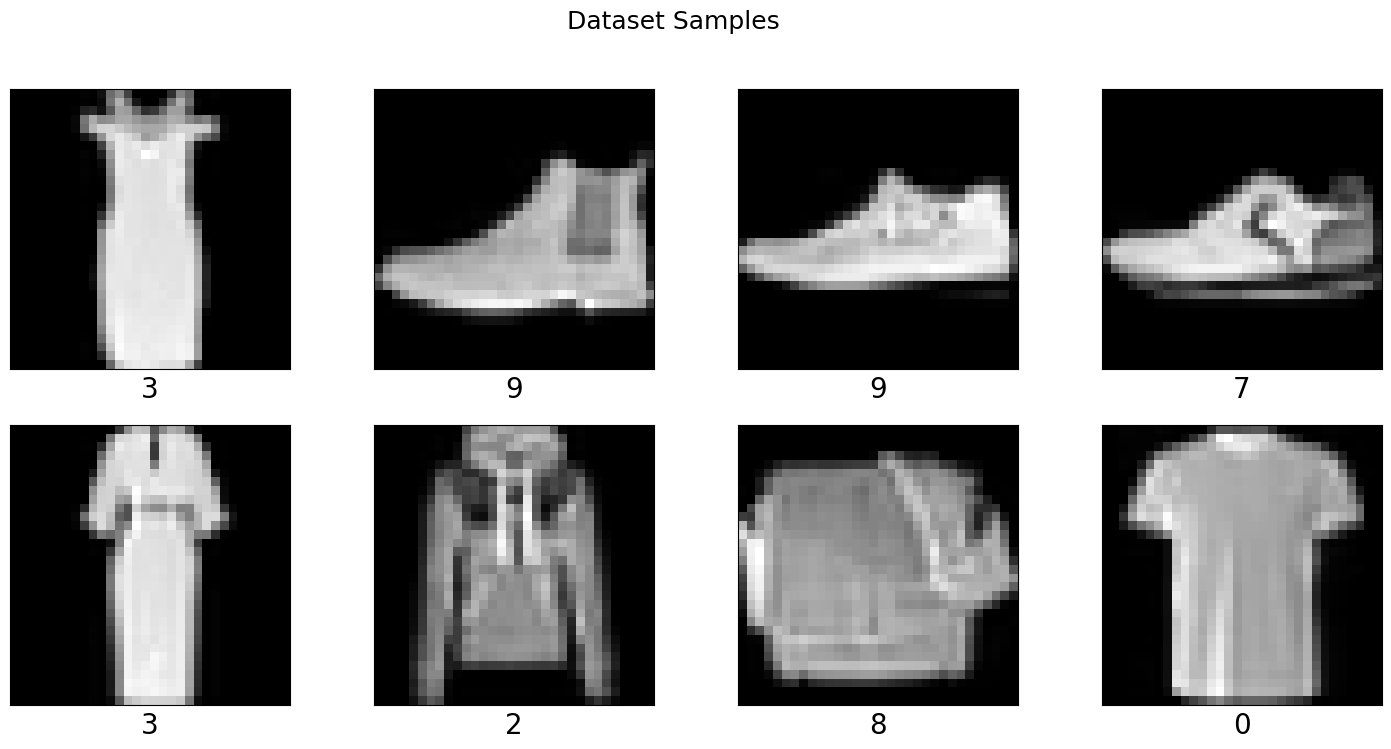

In [8]:
train_loader, valid_loader = get_data(
    resize_dimensions=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
    batch_size=TrainingConfig.BATCH_SIZE,
    data_root=DatasetConfig.DATA_ROOT,
    dataset_mean=DatasetConfig.MEAN,
    dataset_std=DatasetConfig.STD,
)

visualise_samples(valid_loader)

## LeNet5 Model

In [9]:
class LeNet5(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()

        self._body = nn.Sequential(
            nn.Conv2d(
                in_channels=DatasetConfig.IMG_CHANNELS,
                out_channels=6,
                kernel_size=5,
            ),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
            nn.Conv2d(in_channels=6, out_channels=16, kernel_size=5),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2),
        )

        self._head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(in_features=16 * 5 * 5, out_features=120),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=120, out_features=84),
            nn.ReLU(inplace=True),
            nn.Linear(in_features=84, out_features=num_classes),
        )

    def forward(self, x):
        x = self._body(x)

        x = self._head(x)
        return x

In [10]:
model = LeNet5(num_classes=DatasetConfig.NUM_CLASSES)
summary(
    model=model,
    input_size=(
        1,
        DatasetConfig.IMG_CHANNELS,
        DatasetConfig.IMG_HEIGHT,
        DatasetConfig.IMG_WIDTH,
    ),
)

Layer (type:depth-idx)                   Output Shape              Param #
LeNet5                                   [1, 10]                   --
├─Sequential: 1-1                        [1, 16, 5, 5]             --
│    └─Conv2d: 2-1                       [1, 6, 28, 28]            156
│    └─ReLU: 2-2                         [1, 6, 28, 28]            --
│    └─MaxPool2d: 2-3                    [1, 6, 14, 14]            --
│    └─Conv2d: 2-4                       [1, 16, 10, 10]           2,416
│    └─ReLU: 2-5                         [1, 16, 10, 10]           --
│    └─MaxPool2d: 2-6                    [1, 16, 5, 5]             --
├─Sequential: 1-2                        [1, 10]                   --
│    └─Flatten: 2-7                      [1, 400]                  --
│    └─Linear: 2-8                       [1, 120]                  48,120
│    └─ReLU: 2-9                         [1, 120]                  --
│    └─Linear: 2-10                      [1, 84]                   10,164
│  

## Training and Validation Helpers

In [11]:
def train(
    model: nn.Module,
    optimiser: optim.Optimizer,
    train_loader: DataLoader,
    device: torch.device,
    num_classes: int,
    epoch_idx: int,
    total_epochs: int,
):
    model.train()

    loss_record = MeanMetric()
    accuracy_record = MulticlassAccuracy(num_classes=num_classes, average="micro")

    loader_len = len(train_loader)

    with tqdm(total=loader_len, ncols=122, ascii=True) as tq:
        tq.set_description(f"Train :: Epoch: {epoch_idx}/{total_epochs}")

        for data, target in train_loader:
            tq.update(1)

            data = data.to(device)
            target = target.to(device)

            optimiser.zero_grad()

            logits = model(data)
            loss = F.cross_entropy(input=logits, target=target)
            loss.backward()

            optimiser.step()
            loss_record.update(loss.detach().cpu(), weight=data.shape[0])
            predictions = torch.argmax(logits, dim=1)
            accuracy_record.update(predictions.cpu(), target.cpu())

            tq.set_postfix_str(
                s=f"Loss: {loss_record.compute():.4f} Accu: {accuracy_record.compute():.4f}"
            )

    epoch_loss = loss_record.compute()
    epoch_accuracy = accuracy_record.compute()

    return epoch_loss.item(), epoch_accuracy.item()

In [12]:
def validate(
    model: nn.Module,
    valid_loader: DataLoader,
    device: torch.device,
    num_classes: int,
    epoch_idx: int,
    total_epochs: int,
):

    model.eval()

    loss_record = MeanMetric()
    accuracy_record = MulticlassAccuracy(num_classes=num_classes, average="micro")

    loader_len = len(valid_loader)

    with tqdm(total=loader_len, ncols=122, ascii=True) as tq:
        tq.set_description(f"Valid :: Epoch: {epoch_idx}/{total_epochs}")

        for data, target in valid_loader:
            tq.update(1)

            data = data.to(device)
            target = target.to(device)

            with torch.no_grad():
                logits = model(data)

            loss = F.cross_entropy(logits, target)
            loss_record.update(loss.cpu(), weight=data.shape[0])

            predictions = torch.argmax(logits, dim=1)
            accuracy_record.update(predictions.cpu(), target.cpu())

        epoch_loss = loss_record.compute()
        epoch_accuracy = accuracy_record.compute()

        tq.set_postfix_str(s=f"Loss: {epoch_loss:.4f} Acc: {epoch_accuracy:.4f}")

    return epoch_loss.item(), epoch_accuracy.item()

## Training function for the Model

In [13]:
def main(
    model, optimiser: optim.Optimizer, device: torch.device, pin_memeory: bool = False
):
    train_loader, valid_loader = get_data(
        resize_dimensions=(DatasetConfig.IMG_HEIGHT, DatasetConfig.IMG_WIDTH),
        batch_size=TrainingConfig.BATCH_SIZE,
        data_root=DatasetConfig.DATA_ROOT,
        dataset_mean=DatasetConfig.MEAN,
        dataset_std=DatasetConfig.STD,
        pin_memory=pin_memeory,
        num_workers=TrainingConfig.NUM_WORKERS,
    )

    epoch_train_loss = []
    epoch_train_accuracy = []
    epoch_valid_loss = []
    epoch_valid_accuracy = []

    total_epochs = TrainingConfig.NUM_EPOCHS

    # model = torch.compile(model)

    for epoch in range(total_epochs):
        train_loss, train_accuracy = train(
            model=model,
            optimiser=optimiser,
            train_loader=train_loader,
            device=device,
            num_classes=DatasetConfig.NUM_CLASSES,
            epoch_idx=epoch + 1,
            total_epochs=total_epochs,
        )
        valid_loss, valid_accuracy = validate(
            model=model,
            valid_loader=valid_loader,
            device=device,
            num_classes=DatasetConfig.NUM_CLASSES,
            epoch_idx=epoch + 1,
            total_epochs=total_epochs,
        )

        epoch_train_loss.append(train_loss)
        epoch_train_accuracy.append(train_accuracy)
        epoch_valid_loss.append(valid_loss)
        epoch_valid_accuracy.append(valid_accuracy)

    del model
    del optimiser
    del train_loader
    del valid_loader

    gc.collect()
    torch.cuda.empty_cache()

    return (
        epoch_train_loss,
        epoch_train_accuracy,
        epoch_valid_loss,
        epoch_valid_accuracy,
    )

## Training with SGD

In [17]:
model = LeNet5(num_classes=DatasetConfig.NUM_CLASSES)
model.to(DEVICE)

optimiser = optim.SGD(model.parameters(), lr=TrainingConfig.LEARNING_RATE)

sgd_train_loss, sgd_train_accuracy, sgd_valid_loss, sgd_valid_accuracy = main(
    model=model,
    optimiser=optimiser,
    device=DEVICE,
    pin_memeory=IS_GPU_AVAILABLE,
)

Valid :: Epoch: 11/11: 100%|###################################| 79/79 [00:00<00:00, 138.64it/s, Loss: 0.9594 Acc: 0.6444]


## Training with SGD - Momentum

In [16]:
model = LeNet5(num_classes=DatasetConfig.NUM_CLASSES)
model.to(DEVICE)

optimiser = optim.SGD(model.parameters(), lr=TrainingConfig.LEARNING_RATE, momentum=0.9)

sgd_m_train_loss, sgd_m_train_accuracy, sgd_m_valid_loss, sgd_m_valid_accuracy = main(
    model=model,
    optimiser=optimiser,
    device=DEVICE,
    pin_memeory=IS_GPU_AVAILABLE,
)

Valid :: Epoch: 11/11: 100%|###################################| 79/79 [00:00<00:00, 137.38it/s, Loss: 0.4420 Acc: 0.8398]


## Training with RMSProp

In [15]:
model = LeNet5(num_classes=DatasetConfig.NUM_CLASSES)
model.to(DEVICE)

optimiser = optim.RMSprop(model.parameters(), lr=TrainingConfig.LEARNING_RATE)

rmsp_train_loss, rmsp_train_accuracy, rmsp_valid_loss, rmsp_valid_accuracy = main(
    model=model,
    optimiser=optimiser,
    device=DEVICE,
    pin_memeory=IS_GPU_AVAILABLE,
)

Train :: Epoch: 1/11:   0%|                                                                       | 0/469 [00:00<?, ?it/s]/Users/tapasyagutta/workspace/deep-learning/.pytorchVEnv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Valid :: Epoch: 11/11: 100%|###################################| 79/79 [00:00<00:00, 139.81it/s, Loss: 0.2871 Acc: 0.8984]


## Training with Adam (Momentum + RMSProp)

In [14]:
model = LeNet5(num_classes=DatasetConfig.NUM_CLASSES)
model.to(DEVICE)

optimiser = optim.Adam(
    model.parameters(),
    lr=TrainingConfig.LEARNING_RATE,
    fused=DEVICE == torch.device("cuda"),
)

adam_train_loss, adam_train_accuracy, adam_valid_loss, adam_valid_accuracy = main(
    model=model,
    optimiser=optimiser,
    device=DEVICE,
    pin_memeory=IS_GPU_AVAILABLE,
)

Train :: Epoch: 1/11:   0%|                                                                       | 0/469 [00:00<?, ?it/s]/Users/tapasyagutta/workspace/deep-learning/.pytorchVEnv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)
Valid :: Epoch: 11/11: 100%|###################################| 79/79 [00:00<00:00, 139.56it/s, Loss: 0.2760 Acc: 0.8982]


## Plot Loss Curves for Comparison

In [18]:
def plot_results(metrics, ylabel=None, ylim=None, metric_name=None, color=None):
    fig, ax = plt.subplots(figsize=(18, 5))
    ax.set_facecolor("white")

    if not (isinstance(metric_name, list) or isinstance(metric_name, tuple)):
        metrics = [
            metrics,
        ]
        metric_name = [
            metric_name,
        ]

    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])

    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(ylabel + " per Epoch")
    plt.xlim([0, TrainingConfig.NUM_EPOCHS - 1])
    plt.ylim(ylim)
    # Tailor x-axis tick marks
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter("%d"))
    ax.xaxis.set_minor_locator(MultipleLocator(1))
    plt.grid(True)
    plt.legend(metric_name)
    plt.tight_layout()
    plt.savefig(f"{ylabel}.png")
    plt.show()
    plt.close()

### Training Loss

When evaluating optimizers, it's important to study the **training** loss to understand the convergence behavior on the training data. Remember that for a given model and dataset, the job of the optimizer is to perform well on the training data.

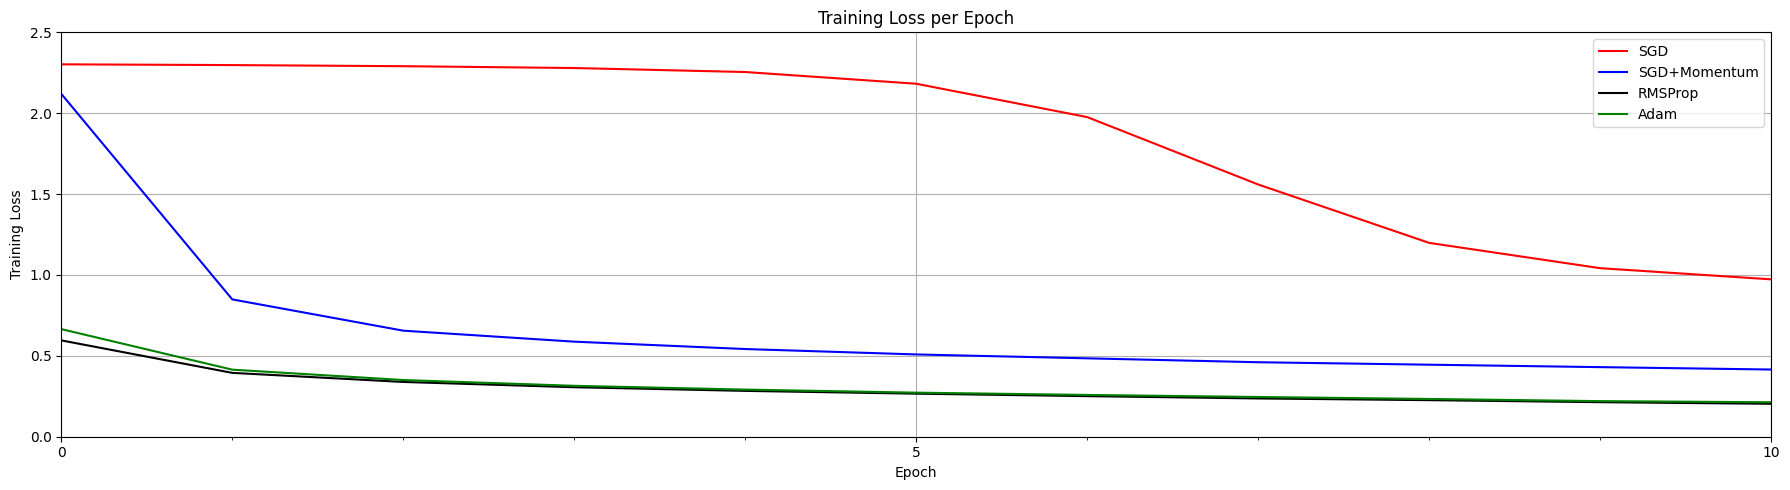

In [19]:
plot_results(
    [sgd_train_loss, sgd_m_train_loss, rmsp_train_loss, adam_train_loss],
    ylabel="Training Loss",
    ylim=[0.0, 2.5],
    metric_name=["SGD", "SGD+Momentum", "RMSProp", "Adam"],
    color=["r", "b", "k", "g"],
)

As shown in the plot above, SGD (red) has the highest loss of the four optimizers, while Adam (green) and RMSProp (black) eventually achieve the lowest loss. Also, notice that SGD+Momentum (blue) follows a very similar trend to Adam, though not quite as low. Initially, RMSProp (black) converges the fastest in the first 10-15 epochs, but at the end the curve is very similar to Adam. So for this model and dataset, Adam and RMSProp clearly perform better than SGD (+ momentum).

But there are a couple of caveats. First, recall that in each case, we used the constant learning rate for each optimizer, which is a good thing to do initially. Once you have a baseline, you can adjust the learning rates for each optimizer to see how that affects the results. Another option is to adjust the learning rate during the training process programmatically by using a learning rate scheduler (we will cover this topic in a future notebook). There is often some experimentation required for selecting the "best" type of optimizer as well as tunning it. The main point here is that it's a good idea to try several optimizers initially. Although *Adam* generally performs very well under a wide range of conditions, it is not necessarily the best choice for all problems, and you should at least experiment initially to see which optimizer looks best. Once you select an optimizer, it is often required to experiment further to finetune the training of your model.

### Validation Loss

Although we often study validation loss when training models, this should not be the criteria by which an optimizer is selected, since the optimizer's job is to achieve fast and stable convergence on the training data. However, it is worth studying the validation loss in this case to make a few points.

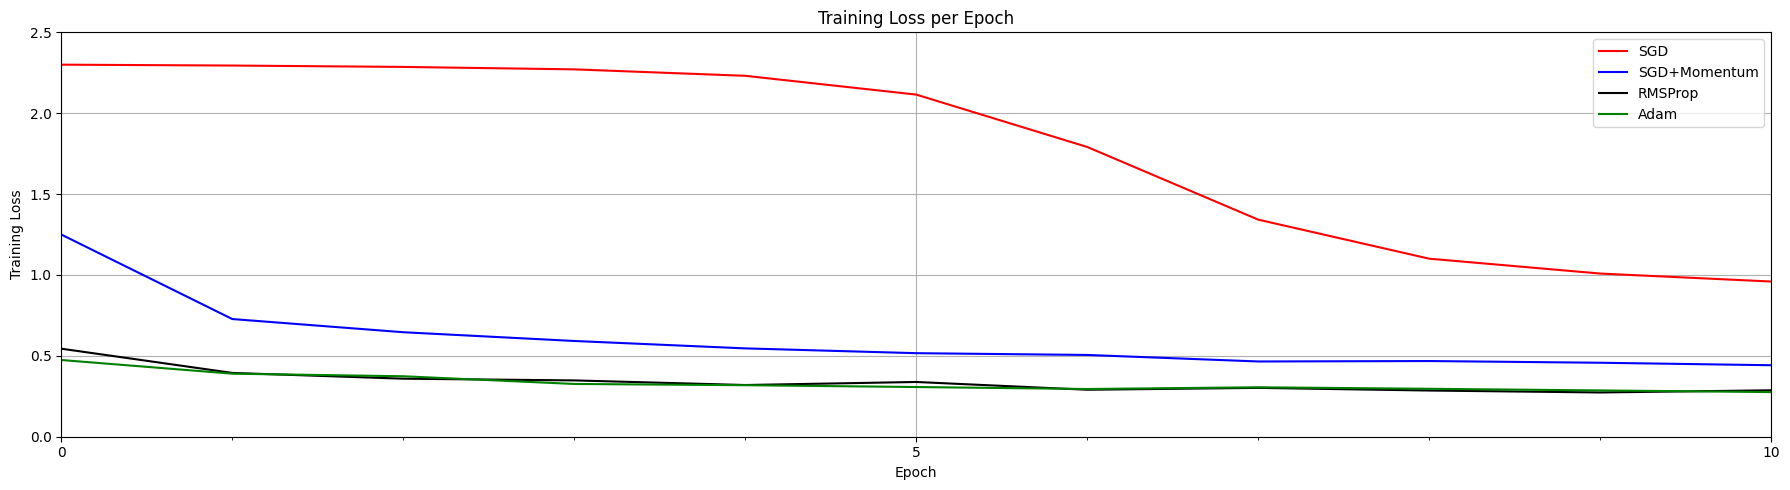

In [20]:
plot_results(
    [sgd_valid_loss, sgd_m_valid_loss, rmsp_valid_loss, adam_valid_loss],
    ylabel="Training Loss",
    ylim=[0.0, 2.5],
    metric_name=["SGD", "SGD+Momentum", "RMSProp", "Adam"],
    color=["r", "b", "k", "g"],
)

In the plot above, we first notice that loss for Adam & RMSProp optimizers start diverging after about 10-15 epochs. The SGD and SGD + momentum optimizer takes longer to converge but flattens out and does not really appear to diverge. So it can be tempting to conclude that SGD and SGD + momentum might be a good choice. But again, we need to remember that while validation loss is important for fine-tuning model and hyperparameters for a given optimizer, this should not be the criteria by which an optimizer is selected.

But if you compare these curves carefully, you will see that Adam, SGD+Momentum, and RMSProp all achieve about the same minimum (validation) loss which is lower than the SGD (red) optimizer, which takes much longer to reach its minimum value. So although we don't want to use validation loss as criteria for selecting the **type** of optimizer to use, the fact that the other three optimizers achieve a lower loss than SGD in just a few epochs is a good indication that they have better convergence properties than SGD.